# PRRSV tblastn Breakdown: Strict Clean

Notebook này validate riêng PRRSV trên strict-clean dataset.

Flow cố định, giống tinh thần FMD notebook:

1. Load helper mới nhất từ source code.
2. Load PRRSV reference model và audit truth annotation/filter.
3. **Chạy lại tblastn validation**, không đọc cache cũ.
4. Tính raw accuracy.
5. Breakdown non-exact cases theo từng gene bằng ref/pred/truth evidence.
6. Sau khi có bằng chứng, mới adjudicate failure mechanism.

Quan trọng: PRRSV khác FMD vì dùng `CDS`/ORF, có overlapping ORFs, `ORF1ab` granularity và ORF1b frameshift/start-boundary convention.

In [61]:
from pathlib import Path
import sys
import importlib

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / 'app').exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import app.validation._shared.validation_utils as validation_utils
importlib.reload(validation_utils)
from app.validation._shared.validation_utils import *

TIER = 'strict_clean'
BASE_DIR = ROOT / 'app' / 'validation' / '04_tblastn_truth_breakdown_100seq' / 'tiers' / TIER
INPUT_DIR = BASE_DIR / 'inputs'
OUTPUT_DIR = BASE_DIR / 'outputs_prrsv'
DATA_DIR = ROOT / 'app' / 'data'

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option('display.max_columns', 120)
pd.set_option('display.max_rows', 120)
plt.rcParams.update({'axes.spines.top': False, 'axes.spines.right': False, 'font.size': 10})

RAW_COLORS = {
    'exact_match': '#2f7d4f',
    'coord_only': '#75b66b',
    'failed_coord_or_name': '#c44e52',
}

BLAME_COLORS = {
    'annotation_convention': '#4c78a8',
    'truth_gap': '#72b7b2',
    'tool': '#c44e52',
}

BASE_DIR, OUTPUT_DIR

(PosixPath('/Users/MacbookProCuaNminh/Desktop/Nminh-Code/Bio-Vin/Phase_2/viralift/app/validation/04_tblastn_truth_breakdown_100seq/tiers/strict_clean'),
 PosixPath('/Users/MacbookProCuaNminh/Desktop/Nminh-Code/Bio-Vin/Phase_2/viralift/app/validation/04_tblastn_truth_breakdown_100seq/tiers/strict_clean/outputs_prrsv'))

## Inputs

Check strict-clean PRRSV input records.

In [62]:
manifest = pd.read_csv(INPUT_DIR / 'manifest.tsv', sep='	')
prrsv_manifest = manifest[manifest['virus'].eq('PRRS')].copy()

input_overview = (
    prrsv_manifest.groupby(['virus', 'keep', 'reason'], dropna=False)
    .size()
    .reset_index(name='records')
    .sort_values(['keep', 'records'], ascending=[False, False])
)
input_overview

,virus,keep,reason,records
2,PRRS,True,kept_clean,95
1,PRRS,False,noncanonical_truth:ignored,4
0,PRRS,False,duplicate_canonical_names,1


## PRRSV Reference CDS Model

The reference model defines which genes ViraLift tries to lift. For PRRSV these are CDS/ORF features, including real overlapping ORFs such as `ORF2a/ORF2b` and `ORF6/ORF7`.

In [63]:
prrsv_bundle = load_reference_bundle(DATA_DIR / 'PRRS_ref_test.gb')
ref_model = pd.DataFrame(prrsv_bundle['features']).copy()
ref_model['ref_len'] = ref_model['end'] - ref_model['start'] + 1
ref_model = (
    ref_model.rename(columns={'name': 'ref_name', 'start': 'ref_start', 'end': 'ref_end'})
    [['ref_name', 'ref_start', 'ref_end', 'ref_len', 'strand']]
    .sort_values(['ref_start', 'ref_end'])
    .reset_index(drop=True)
)
ref_model.to_csv(OUTPUT_DIR / 'prrsv_reference_model.tsv', sep='	', index=False)
ref_model

,ref_name,ref_start,ref_end,ref_len,strand
0,ORF1a,191,7702,7512,+
1,ORF1b,7687,12072,4386,+
2,ORF2a,12074,12844,771,+
3,ORF2b,12079,12300,222,+
4,ORF3,12697,13461,765,+
5,ORF4,13242,13778,537,+
6,ORF5,13789,14391,603,+
7,ORF6,14376,14900,525,+
8,ORF7,14890,15261,372,+


## Truth Annotation Filter Audit

PRRSV validation must not use a blunt nested-feature filter, because some nested/overlapping ORFs are real target genes. The validation helper now uses target-aware truth filtering:

- alias-normalize CDS features
- keep names present in the reference target set
- keep `ORF1ab` as an accepted extra feature for granularity analysis
- keep `ORF2b` even if it overlaps/nests inside `ORF2a`

This section verifies what raw truth contains and what validation truth keeps.

In [64]:
query_records = load_genbank_records(INPUT_DIR / 'PRRS_records.gb')
validation_record_ids = set(prrsv_manifest[prrsv_manifest['keep'].eq(True)]['record_id'])
ref_gene_names = ref_model['ref_name'].dropna().astype(str).tolist()
truth_extra_names = ['ORF1ab']
availability_names = ref_gene_names + [name for name in truth_extra_names if name not in ref_gene_names]
profile_rows = []
presence_rows = []

for record in query_records:
    if record.id not in validation_record_ids:
        continue
    raw_truth_features, _ = parse_truth_features(
        record,
        prrsv_bundle['alias_lookup'],
        prrsv_bundle['feature_type'],
        filter_nested=False,
    )
    validation_truth_features, dropped_features = parse_validation_truth_features(
        record,
        prrsv_bundle['alias_lookup'],
        prrsv_bundle['feature_type'],
        prrsv_bundle['features'],
        'PRRS',
    )

    raw_names = sorted({feature['name'] for feature in raw_truth_features})
    validation_names = sorted({feature['name'] for feature in validation_truth_features})
    dropped_names = sorted({feature['name'] for feature in dropped_features})

    row = {
        'record_id': record.id,
        'raw_truth_feature_count': len(raw_names),
        'validation_truth_feature_count': len(validation_names),
        'raw_truth_names': ', '.join(raw_names),
        'validation_truth_names': ', '.join(validation_names),
        'dropped_non_target_names': ', '.join(dropped_names),
    }
    for name in availability_names:
        raw_has = name in raw_names
        validation_has = name in validation_names
        safe_name = name.replace('/', '_').replace('-', '_')
        row[f'raw_has_{safe_name}'] = raw_has
        row[f'validation_has_{safe_name}'] = validation_has
        row[f'has_{safe_name}'] = validation_has
        presence_rows.append({
            'record_id': record.id,
            'feature': name,
            'is_reference_target': name in ref_gene_names,
            'raw_has_feature': raw_has,
            'validation_has_feature': validation_has,
        })
    profile_rows.append(row)

truth_profile = pd.DataFrame(profile_rows)
truth_presence_long = pd.DataFrame(presence_rows)
truth_profile.to_csv(OUTPUT_DIR / 'prrsv_truth_annotation_profile.tsv', sep='	', index=False)
truth_presence_long.to_csv(OUTPUT_DIR / 'prrsv_truth_presence_by_record_gene.tsv', sep='	', index=False)

truth_profile_summary = (
    truth_presence_long.groupby(['feature', 'is_reference_target'], as_index=False)
    .agg(
        raw_records_with_feature=('raw_has_feature', 'sum'),
        validation_records_with_feature=('validation_has_feature', 'sum'),
        total_records=('record_id', 'nunique'),
    )
)
truth_profile_summary['raw_pct_records'] = (truth_profile_summary['raw_records_with_feature'] / truth_profile_summary['total_records'] * 100).round(2)
truth_profile_summary['validation_pct_records'] = (truth_profile_summary['validation_records_with_feature'] / truth_profile_summary['total_records'] * 100).round(2)
truth_profile_summary = truth_profile_summary.sort_values(['is_reference_target', 'feature'], ascending=[False, True]).reset_index(drop=True)
truth_profile_summary.to_csv(OUTPUT_DIR / 'prrsv_truth_annotation_profile_summary.tsv', sep='	', index=False)
truth_profile_summary


,feature,is_reference_target,raw_records_with_feature,validation_records_with_feature,total_records,raw_pct_records,validation_pct_records
0,ORF1a,True,62,62,95,65.26,65.26
1,ORF1b,True,83,83,95,87.37,87.37
2,ORF2a,True,95,95,95,100.00,100.00
3,ORF2b,True,48,48,95,50.53,50.53
4,ORF3,True,95,95,95,100.00,100.00
5,ORF4,True,95,95,95,100.00,100.00
6,ORF5,True,95,95,95,100.00,100.00
7,ORF6,True,94,94,95,98.95,98.95
8,ORF7,True,94,94,95,98.95,98.95
9,ORF1ab,False,33,33,95,34.74,34.74


## Run PRRSV tblastn And Compare To Truth

This cell intentionally reruns tblastn validation and overwrites PRRSV output files. It does **not** read old cached comparison files, so all downstream tables use the current validation logic.

In [65]:
prrsv_df, prrsv_summary = run_tblastn_against_truth(
    virus_label='PRRS',
    ref_path=DATA_DIR / 'PRRS_ref_test.gb',
    query_path=INPUT_DIR / 'PRRS_records.gb',
    output_dir=OUTPUT_DIR / 'prrs',
    progress=True,
)

prrsv_df.to_csv(OUTPUT_DIR / 'prrsv_tblastn_vs_truth.tsv', sep='	', index=False)
prrsv_summary.to_csv(OUTPUT_DIR / 'prrsv_tblastn_summary.tsv', sep='	', index=False)
prrsv_summary

tblastn  PRRS:   0%|          | 0/95 [00:00<?, ?rec/s]

,virus,method,total,exact,coord_correct,mean_iou,exact_pct,coord_pct
0,PRRS,tblastn,855,638,733,0.8857,74.62,85.73


## Per-Gene Evaluation Denominator

For PRRSV, accuracy should be calculated per reference gene using only records where that gene exists in validation truth. Predictions made in records without same-gene truth are tracked as `extra_predictions_without_truth` and reviewed separately, instead of being mixed into the main accuracy denominator.

In [66]:
def _status_count(series, status):
    return int(series.fillna('').eq(status).sum())

per_gene_rows = []
case_rows = []

for gene in ref_gene_names:
    gene_rows = prrsv_df[prrsv_df['ref_name'].eq(gene)].copy()
    truth_records = set(
        truth_presence_long[
            truth_presence_long['feature'].eq(gene) & truth_presence_long['validation_has_feature'].eq(True)
        ]['record_id']
    )
    evaluable = gene_rows[gene_rows['record_id'].isin(truth_records)].copy()
    extra = gene_rows[~gene_rows['record_id'].isin(truth_records)].copy()
    lifted = gene_rows[pd.to_numeric(gene_rows['pred_start'], errors='coerce').notna()].copy()
    extra_lifted = extra[pd.to_numeric(extra['pred_start'], errors='coerce').notna()].copy()

    exact_correct = int(evaluable['exact_match'].fillna(False).sum())
    coord_correct = int(evaluable['coord_correct'].fillna(False).sum())
    truth_available = len(evaluable)
    lifted_with_truth = int(pd.to_numeric(evaluable['pred_start'], errors='coerce').notna().sum())

    per_gene_rows.append({
        'ref_name': gene,
        'truth_available_records': truth_available,
        'all_records': len(gene_rows),
        'lifted_with_truth': lifted_with_truth,
        'not_lifted_with_truth': _status_count(evaluable['status'], 'no_hit'),
        'exact_correct': exact_correct,
        'coord_correct': coord_correct,
        'exact_wrong_or_nonexact': truth_available - exact_correct,
        'coord_wrong_or_missing': truth_available - coord_correct,
        'extra_predictions_without_truth': len(extra_lifted),
        'records_without_truth': len(extra),
        'exact_pct_on_truth': round(exact_correct / truth_available * 100, 2) if truth_available else None,
        'coord_pct_on_truth': round(coord_correct / truth_available * 100, 2) if truth_available else None,
        'extra_prediction_pct_of_records_without_truth': round(len(extra_lifted) / len(extra) * 100, 2) if len(extra) else None,
    })

    for _, row in evaluable.iterrows():
        case_rows.append({
            'evaluation_type': 'truth_available',
            'ref_name': gene,
            'record_id': row['record_id'],
            'pred_name': row.get('pred_name'),
            'truth_name': row.get('truth_name'),
            'status': row.get('status'),
            'failure_mode': row.get('failure_mode'),
            'exact_match': row.get('exact_match'),
            'coord_correct': row.get('coord_correct'),
            'pred_start': row.get('pred_start'),
            'pred_end': row.get('pred_end'),
            'truth_start': row.get('truth_start'),
            'truth_end': row.get('truth_end'),
            'iou': row.get('iou'),
            'best_overlap_name': row.get('best_overlap_name'),
            'best_iou': row.get('best_iou'),
        })
    for _, row in extra_lifted.iterrows():
        case_rows.append({
            'evaluation_type': 'extra_prediction_without_same_gene_truth',
            'ref_name': gene,
            'record_id': row['record_id'],
            'pred_name': row.get('pred_name'),
            'truth_name': row.get('truth_name'),
            'status': row.get('status'),
            'failure_mode': row.get('failure_mode'),
            'exact_match': row.get('exact_match'),
            'coord_correct': row.get('coord_correct'),
            'pred_start': row.get('pred_start'),
            'pred_end': row.get('pred_end'),
            'truth_start': row.get('truth_start'),
            'truth_end': row.get('truth_end'),
            'iou': row.get('iou'),
            'best_overlap_name': row.get('best_overlap_name'),
            'best_iou': row.get('best_iou'),
        })

per_gene_evaluable_accuracy = pd.DataFrame(per_gene_rows)
per_gene_evaluable_accuracy.to_csv(OUTPUT_DIR / 'prrsv_per_gene_evaluable_accuracy.tsv', sep='	', index=False)

per_gene_evaluation_cases = pd.DataFrame(case_rows)
per_gene_evaluation_cases.to_csv(OUTPUT_DIR / 'prrsv_per_gene_evaluation_cases.tsv', sep='	', index=False)
per_gene_evaluable_accuracy

,ref_name,truth_available_records,all_records,lifted_with_truth,not_lifted_with_truth,exact_correct,coord_correct,exact_wrong_or_nonexact,coord_wrong_or_missing,extra_predictions_without_truth,records_without_truth,exact_pct_on_truth,coord_pct_on_truth,extra_prediction_pct_of_records_without_truth
0,ORF1a,62,95,62,0,61,62,1,0,33,33,98.39,100.00,100.0
1,ORF1b,83,95,83,0,0,83,83,0,12,12,0.00,100.00,100.0
2,ORF2a,95,95,95,0,95,95,0,0,0,0,100.00,100.00,NaN
3,ORF2b,48,95,48,0,45,48,3,0,47,47,93.75,100.00,100.0
4,ORF3,95,95,95,0,95,95,0,0,0,0,100.00,100.00,NaN
5,ORF4,95,95,95,0,94,95,1,0,0,0,98.95,100.00,NaN
6,ORF5,95,95,95,0,91,95,4,0,0,0,95.79,100.00,NaN
7,ORF6,94,95,94,0,91,94,3,0,1,1,96.81,100.00,100.0
8,ORF7,94,95,94,0,66,66,28,28,1,1,70.21,70.21,100.0


## Overall Accuracy On Evaluable Truth Features

This is the fairer PRRSV headline metric: denominator = reference-gene features that actually exist in the query truth annotation. Extra predictions without same-gene truth are kept as a separate review category.

In [67]:
total_truth_features = int(per_gene_evaluable_accuracy['truth_available_records'].sum())
total_exact = int(per_gene_evaluable_accuracy['exact_correct'].sum())
total_coord = int(per_gene_evaluable_accuracy['coord_correct'].sum())
total_extra = int(per_gene_evaluable_accuracy['extra_predictions_without_truth'].sum())

evaluable_accuracy = pd.DataFrame([
    {
        'virus': 'PRRSV',
        'truth_available_ref_gene_features': total_truth_features,
        'exact_correct': total_exact,
        'coord_correct': total_coord,
        'exact_pct_on_truth': round(total_exact / total_truth_features * 100, 2) if total_truth_features else 0,
        'coord_pct_on_truth': round(total_coord / total_truth_features * 100, 2) if total_truth_features else 0,
        'extra_predictions_without_same_gene_truth': total_extra,
    }
])
evaluable_accuracy.to_csv(OUTPUT_DIR / 'prrsv_evaluable_accuracy.tsv', sep='	', index=False)
evaluable_accuracy

,virus,truth_available_ref_gene_features,exact_correct,coord_correct,exact_pct_on_truth,coord_pct_on_truth,extra_predictions_without_same_gene_truth
0,PRRSV,761,638,733,83.84,96.32,94


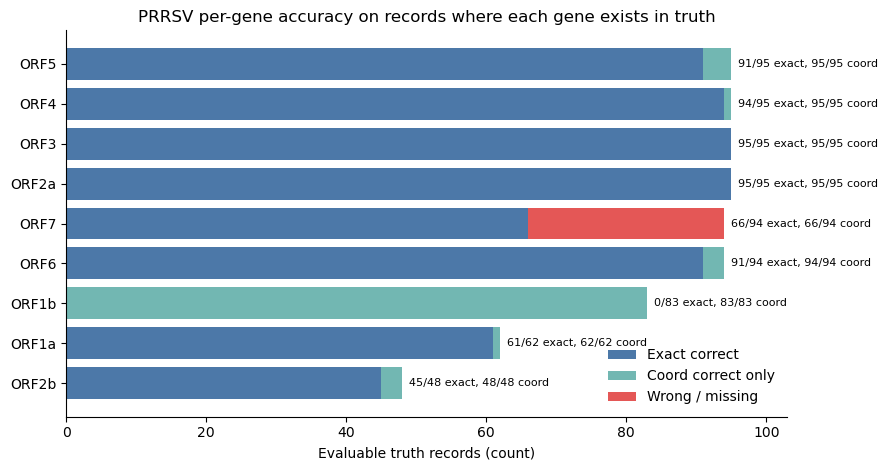

In [68]:
plot_df = per_gene_evaluable_accuracy.sort_values('truth_available_records', ascending=True).copy()
plot_df['coord_only'] = plot_df['coord_correct'] - plot_df['exact_correct']
plot_df['wrong_or_missing'] = plot_df['truth_available_records'] - plot_df['coord_correct']

fig, ax = plt.subplots(figsize=(9, 4.8))
y = plot_df['ref_name']
ax.barh(y, plot_df['exact_correct'], label='Exact correct', color='#4C78A8')
ax.barh(y, plot_df['coord_only'], left=plot_df['exact_correct'], label='Coord correct only', color='#72B7B2')
ax.barh(
    y,
    plot_df['wrong_or_missing'],
    left=plot_df['coord_correct'],
    label='Wrong / missing',
    color='#E45756',
)
ax.set_xlabel('Evaluable truth records (count)')
ax.set_ylabel('')
ax.set_title('PRRSV per-gene accuracy on records where each gene exists in truth')
ax.legend(frameon=False, loc='lower right')

max_n = int(plot_df['truth_available_records'].max()) if not plot_df.empty else 0
ax.set_xlim(0, max_n + 8)
for _, row in plot_df.iterrows():
    label = (
        f"{int(row['exact_correct'])}/{int(row['truth_available_records'])} exact, "
        f"{int(row['coord_correct'])}/{int(row['truth_available_records'])} coord"
    )
    ax.text(row['truth_available_records'] + 1, row['ref_name'], label, va='center', ha='left', fontsize=8)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'prrsv_per_gene_evaluable_accuracy.png', bbox_inches='tight')
plt.show()


## Immediate ORF2b Sanity Check

This check confirms that the notebook is using the new target-aware validation truth. If `ORF2b exact = 0` and `truth_name` is absent for all 95 records, the kernel is stale or the notebook did not rerun from the setup cell.

In [69]:
orf2b_check = prrsv_df[prrsv_df['pred_name'].eq('ORF2b')].copy()
orf2b_check_summary = (
    orf2b_check.groupby(['truth_name', 'failure_mode'], dropna=False)
    .size()
    .reset_index(name='cases')
    .sort_values('cases', ascending=False)
)
print('ORF2b exact:', int(orf2b_check['exact_match'].sum()))
print('ORF2b coord:', int(orf2b_check['coord_correct'].sum()))
print('ORF2b total:', len(orf2b_check))
orf2b_check_summary

ORF2b exact: 45
ORF2b coord: 48
ORF2b total: 95


,truth_name,failure_mode,cases
2,NaN,Possible overlap,47
1,ORF2b,Correct,45
0,ORF2b,Boundary offset,3


## Raw Prediction-Level Accuracy

This older/raw metric uses every prediction row as the denominator, including records where the query truth lacks that gene. Keep it for comparison, but use `Overall Accuracy On Evaluable Truth Features` as the main PRRSV accuracy metric.

In [70]:
total = len(prrsv_df)
exact = int(prrsv_df['exact_match'].fillna(False).sum())
coord = int(prrsv_df['coord_correct'].fillna(False).sum())
coord_only = coord - exact
failed = total - coord
non_exact = total - exact

raw_accuracy = pd.DataFrame([
    {
        'virus': 'PRRSV',
        'total_predictions': total,
        'exact_match': exact,
        'coord_only': coord_only,
        'failed_coord_or_name': failed,
        'non_exact': non_exact,
        'exact_pct': round(exact / total * 100, 2) if total else 0,
        'coord_pct': round(coord / total * 100, 2) if total else 0,
        'failed_pct': round(failed / total * 100, 2) if total else 0,
        'non_exact_pct': round(non_exact / total * 100, 2) if total else 0,
    }
])
raw_accuracy.to_csv(OUTPUT_DIR / 'prrsv_raw_accuracy.tsv', sep='	', index=False)
raw_accuracy

,virus,total_predictions,exact_match,coord_only,failed_coord_or_name,non_exact,exact_pct,coord_pct,failed_pct,non_exact_pct
0,PRRSV,855,638,95,122,217,74.62,85.73,14.27,25.38


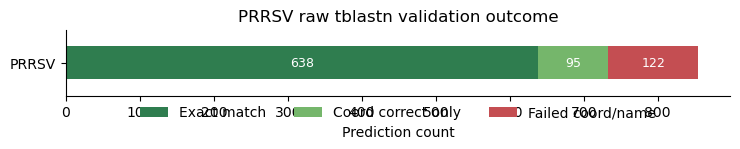

In [71]:
plot_df = raw_accuracy.set_index('virus')[['exact_match', 'coord_only', 'failed_coord_or_name']]
ax = plot_df.plot(kind='barh', stacked=True, color=[RAW_COLORS[c] for c in plot_df.columns], figsize=(7.5, 1.9))
ax.set_xlabel('Prediction count')
ax.set_ylabel('')
ax.set_title('PRRSV raw tblastn validation outcome')
ax.legend(['Exact match', 'Coord correct only', 'Failed coord/name'], loc='lower center', bbox_to_anchor=(0.5, -0.55), ncol=3, frameon=False)
for container in ax.containers:
    ax.bar_label(container, label_type='center', color='white', fontsize=9)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'prrsv_raw_accuracy.png', bbox_inches='tight')
plt.show()

## Why PRRSV Is Different From FMD

FMD validation mainly uses `mat_peptide` features from a polyprotein. PRRSV validation uses `CDS`/ORF features.

Important PRRSV-specific mechanisms:

- `ORF1a` / `ORF1b` / `ORF1ab`: some records split ORF1a and ORF1b, while others annotate a combined ORF1ab region.
- `ORF1b`: start boundary can be affected by frameshift/start convention; end can match exactly while start differs.
- `ORF2a` / `ORF2b`: ORF2b overlaps ORF2a and may be absent as a separate truth feature in some records.
- `ORF5` / `ORF6` / `ORF7`: structural ORFs can be adjacent/overlapping, so small boundary offsets need case-level review.

## Evaluable Failure Evidence Table

From this point onward, the main breakdown only uses non-exact cases where the same reference gene exists in query truth. Predictions made in records without same-gene truth are exported separately as `extra_predictions_without_truth`, because they are not valid accuracy-denominator cases.

In [72]:
def _format_delta(series):
    values = pd.to_numeric(series, errors='coerce').dropna()
    if values.empty:
        return ''
    counts = values.astype(int).value_counts().sort_index()
    return ', '.join(f'{idx}:{count}' for idx, count in counts.items())


def _top_value(series):
    series = series.dropna()
    if series.empty:
        return None
    return series.value_counts().idxmax()


def _prepare_evidence_table(df):
    df = df.copy()
    numeric_cols = ['pred_start', 'pred_end', 'truth_start', 'truth_end', 'iou', 'best_iou', 'coverage', 'identity']
    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
    df['delta_start'] = df['pred_start'] - df['truth_start']
    df['delta_end'] = df['pred_end'] - df['truth_end']
    df['pred_len'] = df['pred_end'] - df['pred_start'] + 1
    df['truth_len'] = df['truth_end'] - df['truth_start'] + 1
    if 'ref_len' not in df.columns:
        df = df.merge(ref_model[['ref_name', 'ref_len']], on='ref_name', how='left')
    df['pred_minus_ref_len'] = df['pred_len'] - df['ref_len']
    df['truth_minus_ref_len'] = df['truth_len'] - df['ref_len']
    df['pred_minus_truth_len'] = df['pred_len'] - df['truth_len']
    return df


non_exact_cases = per_gene_evaluation_cases[~per_gene_evaluation_cases['exact_match'].fillna(False)].copy()
failures = _prepare_evidence_table(
    non_exact_cases[non_exact_cases['evaluation_type'].eq('truth_available')]
)
extra_predictions_without_truth = _prepare_evidence_table(
    per_gene_evaluation_cases[per_gene_evaluation_cases['evaluation_type'].eq('extra_prediction_without_same_gene_truth')]
)

failures.to_csv(OUTPUT_DIR / 'prrsv_evaluable_failure_cases_with_ref.tsv', sep='	', index=False)
extra_predictions_without_truth.to_csv(OUTPUT_DIR / 'prrsv_extra_predictions_without_truth.tsv', sep='	', index=False)

failure_by_gene = (
    failures.groupby(['ref_name', 'pred_name'], dropna=False)
    .agg(
        non_exact_evaluable_cases=('record_id', 'size'),
        main_failure_mode=('failure_mode', _top_value),
        main_status=('status', _top_value),
        main_best_overlap=('best_overlap_name', _top_value),
        delta_start_pattern=('delta_start', _format_delta),
        delta_end_pattern=('delta_end', _format_delta),
        pred_minus_ref_pattern=('pred_minus_ref_len', _format_delta),
        truth_minus_ref_pattern=('truth_minus_ref_len', _format_delta),
        mean_iou=('iou', 'mean'),
        mean_best_iou=('best_iou', 'mean'),
    )
    .reset_index()
    .sort_values(['non_exact_evaluable_cases', 'ref_name'], ascending=[False, True])
)
if not failure_by_gene.empty:
    failure_by_gene['mean_iou'] = failure_by_gene['mean_iou'].round(4)
    failure_by_gene['mean_best_iou'] = failure_by_gene['mean_best_iou'].round(4)
failure_by_gene.to_csv(OUTPUT_DIR / 'prrsv_evaluable_failure_by_gene.tsv', sep='	', index=False)
failure_by_gene

,ref_name,pred_name,non_exact_evaluable_cases,main_failure_mode,main_status,main_best_overlap,delta_start_pattern,delta_end_pattern,pred_minus_ref_pattern,truth_minus_ref_pattern,mean_iou,mean_best_iou
1,ORF1b,ORF1b,83,Boundary offset,invalid_boundaries,ORF1b,"-75:1, -12:39, -9:2, -3:28, 6:12, 15:1",0:83,"-27:1, -3:1, 0:80, 3:1","-75:1, -15:1, -12:38, -9:3, -3:28, 6:12",0.9980,0.9980
6,ORF7,ORF7,28,Wrong coords,ok_rescued,ORF7,"43:25, 48:3",0:28,"-43:25, -33:3","0:25, 15:3",0.8835,0.8835
4,ORF5,ORF5,4,Boundary offset,ok_rescued,ORF5,5:4,0:4,-2:4,3:4,0.9917,0.9917
2,ORF2b,ORF2b,3,Boundary offset,ok_rescued,ORF2b,-5:3,0:3,-4:3,-9:3,0.9771,0.9771
5,ORF6,ORF6,3,Boundary offset,ok_rescued,ORF6,13:3,0:3,-16:3,-3:3,0.9751,0.9751
0,ORF1a,ORF1a,1,Boundary offset,ok,ORF1a,0:1,13:1,108:1,95:1,0.9983,0.9983
3,ORF4,ORF4,1,Boundary offset,ok_rescued,ORF4,45:1,0:1,-30:1,15:1,0.9185,0.9185


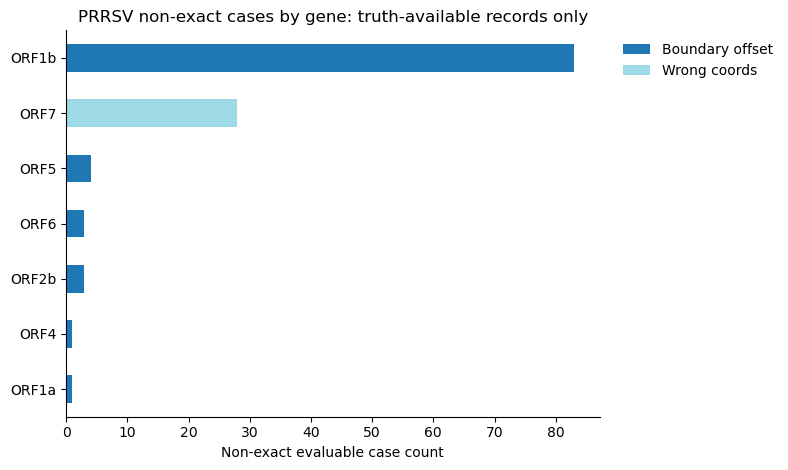

In [73]:
if failures.empty:
    print('No PRRSV non-exact cases among truth-available records.')
else:
    plot_counts = (
        failures.groupby(['pred_name', 'failure_mode'], dropna=False)
        .size()
        .reset_index(name='cases')
        .sort_values('cases', ascending=False)
    )
    pivot = plot_counts.pivot_table(index='pred_name', columns='failure_mode', values='cases', fill_value=0)
    pivot = pivot.loc[pivot.sum(axis=1).sort_values(ascending=True).index]
    ax = pivot.plot(kind='barh', stacked=True, figsize=(8, 4.8), colormap='tab20')
    ax.set_title('PRRSV non-exact cases by gene: truth-available records only')
    ax.set_xlabel('Non-exact evaluable case count')
    ax.set_ylabel('')
    ax.legend(title='', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'prrsv_evaluable_failure_by_gene.png', bbox_inches='tight')
    plt.show()

## Gene-By-Gene Evidence Before Adjudication

The next sections inspect only `truth_available` non-exact cases, so each row has a same-gene ground truth answer. Extra predictions in records without same-gene truth are shown separately after the gene breakdown.

In [74]:
gene_rank = (
    failures.groupby('pred_name', dropna=False)
    .agg(
        non_exact_evaluable_cases=('record_id', 'size'),
        main_failure_mode=('failure_mode', _top_value),
        main_status=('status', _top_value),
        main_best_overlap=('best_overlap_name', _top_value),
        delta_start_pattern=('delta_start', _format_delta),
        delta_end_pattern=('delta_end', _format_delta),
        pred_minus_ref_pattern=('pred_minus_ref_len', _format_delta),
        truth_minus_ref_pattern=('truth_minus_ref_len', _format_delta),
        mean_iou=('iou', 'mean'),
        mean_best_iou=('best_iou', 'mean'),
    )
    .reset_index()
    .sort_values('non_exact_evaluable_cases', ascending=False)
)
if not gene_rank.empty:
    gene_rank['mean_iou'] = gene_rank['mean_iou'].round(4)
    gene_rank['mean_best_iou'] = gene_rank['mean_best_iou'].round(4)
gene_rank.to_csv(OUTPUT_DIR / 'prrsv_evaluable_non_exact_gene_rank.tsv', sep='	', index=False)
gene_rank

,pred_name,non_exact_evaluable_cases,main_failure_mode,main_status,main_best_overlap,delta_start_pattern,delta_end_pattern,pred_minus_ref_pattern,truth_minus_ref_pattern,mean_iou,mean_best_iou
1,ORF1b,83,Boundary offset,invalid_boundaries,ORF1b,"-75:1, -12:39, -9:2, -3:28, 6:12, 15:1",0:83,"-27:1, -3:1, 0:80, 3:1","-75:1, -15:1, -12:38, -9:3, -3:28, 6:12",0.9980,0.9980
6,ORF7,28,Wrong coords,ok_rescued,ORF7,"43:25, 48:3",0:28,"-43:25, -33:3","0:25, 15:3",0.8835,0.8835
4,ORF5,4,Boundary offset,ok_rescued,ORF5,5:4,0:4,-2:4,3:4,0.9917,0.9917
2,ORF2b,3,Boundary offset,ok_rescued,ORF2b,-5:3,0:3,-4:3,-9:3,0.9771,0.9771
5,ORF6,3,Boundary offset,ok_rescued,ORF6,13:3,0:3,-16:3,-3:3,0.9751,0.9751
0,ORF1a,1,Boundary offset,ok,ORF1a,0:1,13:1,108:1,95:1,0.9983,0.9983
3,ORF4,1,Boundary offset,ok_rescued,ORF4,45:1,0:1,-30:1,15:1,0.9185,0.9185


In [75]:
EVIDENCE_COLS = [
    'evaluation_type', 'record_id', 'ref_name', 'pred_name', 'truth_name', 'best_overlap_name',
    'ref_len', 'pred_len', 'truth_len', 'pred_minus_ref_len', 'truth_minus_ref_len', 'pred_minus_truth_len',
    'pred_start', 'pred_end', 'truth_start', 'truth_end', 'delta_start', 'delta_end',
    'failure_mode', 'status', 'coverage', 'identity', 'iou', 'best_iou',
]


def evidence_for_gene(gene, extra_filter=None, sort_cols=None, source='evaluable'):
    source_df = extra_predictions_without_truth if source == 'extra_without_truth' else failures
    df = source_df[source_df['pred_name'].eq(gene)].copy()
    if extra_filter is not None:
        df = df[extra_filter(df)].copy()
    cols = [c for c in EVIDENCE_COLS if c in df.columns]
    if sort_cols is None:
        sort_cols = ['failure_mode', 'status', 'record_id']
    sort_cols = [c for c in sort_cols if c in df.columns]
    if sort_cols:
        return df[cols].sort_values(sort_cols, na_position='last')
    return df[cols]


def compact_gene_summary(df):
    if df.empty:
        return pd.DataFrame()
    summary = (
        df.groupby(['pred_name', 'failure_mode', 'status', 'truth_name', 'best_overlap_name'], dropna=False)
        .agg(
            cases=('record_id', 'size'),
            delta_start_pattern=('delta_start', _format_delta),
            delta_end_pattern=('delta_end', _format_delta),
            pred_minus_ref_pattern=('pred_minus_ref_len', _format_delta),
            truth_minus_ref_pattern=('truth_minus_ref_len', _format_delta),
            mean_iou=('iou', 'mean'),
            mean_best_iou=('best_iou', 'mean'),
        )
        .reset_index()
        .sort_values('cases', ascending=False)
    )
    summary['mean_iou'] = summary['mean_iou'].round(4)
    summary['mean_best_iou'] = summary['mean_best_iou'].round(4)
    return summary


def plot_delta_patterns(df, title, out_name):
    plot_df = df[['delta_start', 'delta_end']].copy()
    plot_df = plot_df.apply(pd.to_numeric, errors='coerce')
    if plot_df.dropna(how='all').empty:
        print('No delta values to plot.')
        return
    fig, axes = plt.subplots(1, 2, figsize=(8, 2.8))
    for ax, col, color in zip(axes, ['delta_start', 'delta_end'], ['#4c78a8', '#c44e52']):
        values = plot_df[col].dropna().astype(int)
        if values.empty:
            ax.text(0.5, 0.5, 'no values', ha='center', va='center')
            ax.set_axis_off()
            continue
        counts = values.value_counts().sort_index()
        counts.plot(kind='bar', ax=ax, color=color)
        ax.set_title(col)
        ax.set_xlabel('bp offset')
        ax.set_ylabel('cases')
    fig.suptitle(title)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / out_name, bbox_inches='tight')
    plt.show()

### ORF2b Evidence

This section now shows only ORF2b cases where query truth contains ORF2b. Extra ORF2b predictions in records without ORF2b truth are reviewed separately later.

In [76]:
orf2b_evidence = evidence_for_gene('ORF2b')
orf2b_evidence.to_csv(OUTPUT_DIR / 'prrsv_gene_ORF2b_evidence.tsv', sep='	', index=False)
compact_gene_summary(orf2b_evidence)

,pred_name,failure_mode,status,truth_name,best_overlap_name,cases,delta_start_pattern,delta_end_pattern,pred_minus_ref_pattern,truth_minus_ref_pattern,mean_iou,mean_best_iou
0,ORF2b,Boundary offset,ok_rescued,ORF2b,ORF2b,3,-5:3,0:3,-4:3,-9:3,0.9771,0.9771


In [77]:
orf2b_display_cols = [
    'record_id', 'ref_name', 'pred_name', 'truth_name', 'best_overlap_name',
    'ref_len', 'pred_len', 'truth_len', 'pred_minus_ref_len', 'truth_minus_ref_len', 'pred_minus_truth_len',
    'pred_start', 'pred_end', 'truth_start', 'truth_end', 'delta_start', 'delta_end',
    'failure_mode', 'status', 'coverage', 'identity', 'iou', 'best_iou'
]
orf2b_evidence[[c for c in orf2b_display_cols if c in orf2b_evidence.columns]].head(40)

,record_id,ref_name,pred_name,truth_name,best_overlap_name,ref_len,pred_len,truth_len,pred_minus_ref_len,truth_minus_ref_len,pred_minus_truth_len,pred_start,pred_end,truth_start,truth_end,delta_start,delta_end,failure_mode,status,iou,best_iou
84,AY366525.1,ORF2b,ORF2b,ORF2b,ORF2b,222,218,213.0,-4,-9.0,5.0,11745,11962,11750.0,11962.0,-5.0,0.0,Boundary offset,ok_rescued,0.9771,0.9771
85,DQ489311.1,ORF2b,ORF2b,ORF2b,ORF2b,222,218,213.0,-4,-9.0,5.0,11745,11962,11750.0,11962.0,-5.0,0.0,Boundary offset,ok_rescued,0.9771,0.9771
86,EU076704.1,ORF2b,ORF2b,ORF2b,ORF2b,222,218,213.0,-4,-9.0,5.0,11796,12013,11801.0,12013.0,-5.0,0.0,Boundary offset,ok_rescued,0.9771,0.9771


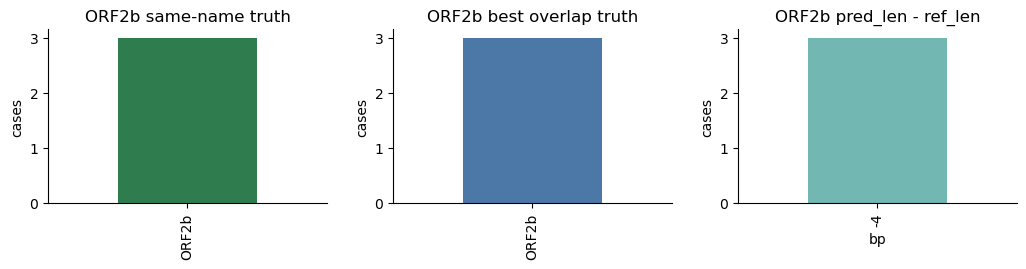

In [78]:
if not orf2b_evidence.empty:
    fig, axes = plt.subplots(1, 3, figsize=(10.5, 2.8))
    orf2b_evidence['truth_name'].fillna('truth absent').replace('', 'truth absent').value_counts().plot(kind='bar', ax=axes[0], color='#2f7d4f')
    axes[0].set_title('ORF2b same-name truth')
    axes[0].set_xlabel('')
    axes[0].set_ylabel('cases')

    orf2b_evidence['best_overlap_name'].fillna('None').replace('', 'None').value_counts().plot(kind='bar', ax=axes[1], color='#4c78a8')
    axes[1].set_title('ORF2b best overlap truth')
    axes[1].set_xlabel('')
    axes[1].set_ylabel('cases')

    orf2b_evidence['pred_minus_ref_len'].dropna().astype(int).value_counts().sort_index().plot(kind='bar', ax=axes[2], color='#72b7b2')
    axes[2].set_title('ORF2b pred_len - ref_len')
    axes[2].set_xlabel('bp')
    axes[2].set_ylabel('cases')

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'prrsv_orf2b_evidence.png', bbox_inches='tight')
    plt.show()

### ORF1b Evidence: Frameshift / Start Boundary Pattern

In [79]:
orf1b_evidence = evidence_for_gene('ORF1b')
orf1b_evidence.to_csv(OUTPUT_DIR / 'prrsv_gene_ORF1b_evidence.tsv', sep='	', index=False)
compact_gene_summary(orf1b_evidence)

,pred_name,failure_mode,status,truth_name,best_overlap_name,cases,delta_start_pattern,delta_end_pattern,pred_minus_ref_pattern,truth_minus_ref_pattern,mean_iou,mean_best_iou
0,ORF1b,Boundary offset,invalid_boundaries,ORF1b,ORF1b,82,"-75:1, -12:39, -9:2, -3:28, 6:12",0:82,"-3:1, 0:80, 3:1","-75:1, -15:1, -12:37, -9:3, -3:28, 6:12",0.9980,0.9980
1,ORF1b,Boundary offset,ok_rescued,ORF1b,ORF1b,1,15:1,0:1,-27:1,-12:1,0.9966,0.9966


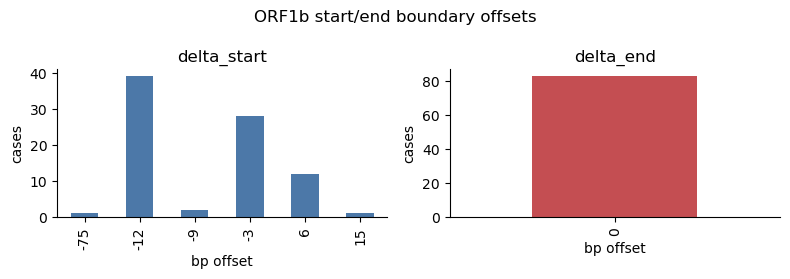

,record_id,ref_name,pred_name,truth_name,best_overlap_name,ref_len,pred_len,truth_len,pred_minus_ref_len,truth_minus_ref_len,delta_start,delta_end,failure_mode,status,iou
67,AB288356.1,ORF1b,ORF1b,ORF1b,ORF1b,4386,4386,4374.0,0,-12.0,-12.0,0.0,Boundary offset,invalid_boundaries,0.9973
79,AB811785.1,ORF1b,ORF1b,ORF1b,ORF1b,4386,4386,4374.0,0,-12.0,-12.0,0.0,Boundary offset,invalid_boundaries,0.9973
80,AB811786.1,ORF1b,ORF1b,ORF1b,ORF1b,4386,4386,4374.0,0,-12.0,-12.0,0.0,Boundary offset,invalid_boundaries,0.9973
81,AB811787.1,ORF1b,ORF1b,ORF1b,ORF1b,4386,4386,4374.0,0,-12.0,-12.0,0.0,Boundary offset,invalid_boundaries,0.9973
82,AB811788.1,ORF1b,ORF1b,ORF1b,ORF1b,4386,4386,4374.0,0,-12.0,-12.0,0.0,Boundary offset,invalid_boundaries,0.9973
83,AB811789.1,ORF1b,ORF1b,ORF1b,ORF1b,4386,4386,4374.0,0,-12.0,-12.0,0.0,Boundary offset,invalid_boundaries,0.9973
17,AF066183.4,ORF1b,ORF1b,ORF1b,ORF1b,4386,4386,4374.0,0,-12.0,-12.0,0.0,Boundary offset,invalid_boundaries,0.9973
2,AF159149.1,ORF1b,ORF1b,ORF1b,ORF1b,4386,4386,4392.0,0,6.0,6.0,0.0,Boundary offset,invalid_boundaries,0.9986
6,AF176348.2,ORF1b,ORF1b,ORF1b,ORF1b,4386,4386,4392.0,0,6.0,6.0,0.0,Boundary offset,invalid_boundaries,0.9986
1,AF184212.1,ORF1b,ORF1b,ORF1b,ORF1b,4386,4386,4392.0,0,6.0,6.0,0.0,Boundary offset,invalid_boundaries,0.9986


In [80]:
plot_delta_patterns(orf1b_evidence, 'ORF1b start/end boundary offsets', 'prrsv_orf1b_delta_patterns.png')
orf1b_display_cols = [
    'record_id', 'ref_name', 'pred_name', 'truth_name', 'best_overlap_name',
    'ref_len', 'pred_len', 'truth_len', 'pred_minus_ref_len', 'truth_minus_ref_len',
    'delta_start', 'delta_end', 'failure_mode', 'status', 'coverage', 'identity', 'iou'
]
orf1b_evidence[[c for c in orf1b_display_cols if c in orf1b_evidence.columns]].head(35)

### ORF1a Evidence: ORF1a/ORF1b vs ORF1ab Granularity

In [81]:
orf1a_evidence = evidence_for_gene('ORF1a')
orf1a_evidence.to_csv(OUTPUT_DIR / 'prrsv_gene_ORF1a_evidence.tsv', sep='	', index=False)
compact_gene_summary(orf1a_evidence)

,pred_name,failure_mode,status,truth_name,best_overlap_name,cases,delta_start_pattern,delta_end_pattern,pred_minus_ref_pattern,truth_minus_ref_pattern,mean_iou,mean_best_iou
0,ORF1a,Boundary offset,ok,ORF1a,ORF1a,1,0:1,13:1,108:1,95:1,0.9983,0.9983


In [82]:
orf1a_profile = orf1a_evidence.merge(
    truth_profile[['record_id', 'has_ORF1a', 'has_ORF1b', 'has_ORF1ab', 'validation_truth_names']],
    on='record_id',
    how='left',
)
orf1a_profile_cols = [
    'record_id', 'pred_name', 'truth_name', 'best_overlap_name',
    'has_ORF1a', 'has_ORF1b', 'has_ORF1ab',
    'pred_start', 'pred_end', 'truth_start', 'truth_end', 'best_iou', 'failure_mode', 'status',
]
orf1a_profile[[c for c in orf1a_profile_cols if c in orf1a_profile.columns]].head(35)

,record_id,pred_name,truth_name,best_overlap_name,has_ORF1a,has_ORF1b,has_ORF1ab,pred_start,pred_end,truth_start,truth_end,best_iou,failure_mode,status
0,DQ779791.1,ORF1a,ORF1a,ORF1a,True,True,False,191,7810,191.0,7797.0,0.9983,Boundary offset,ok


### ORF7 Evidence: Candidate Tool-Side Boundary Issue

In [83]:
orf7_evidence = evidence_for_gene('ORF7')
orf7_evidence.to_csv(OUTPUT_DIR / 'prrsv_gene_ORF7_evidence.tsv', sep='	', index=False)
compact_gene_summary(orf7_evidence)

,pred_name,failure_mode,status,truth_name,best_overlap_name,cases,delta_start_pattern,delta_end_pattern,pred_minus_ref_pattern,truth_minus_ref_pattern,mean_iou,mean_best_iou
0,ORF7,Wrong coords,ok_rescued,ORF7,ORF7,28,"43:25, 48:3",0:28,"-43:25, -33:3","0:25, 15:3",0.8835,0.8835


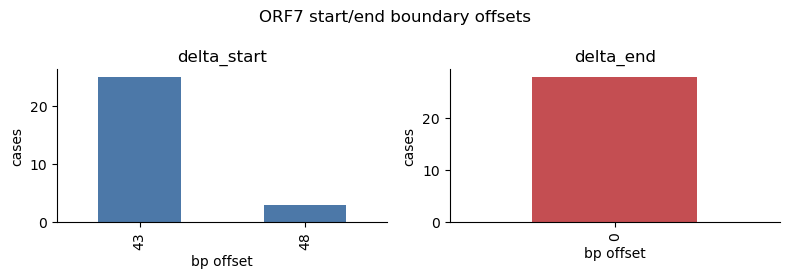

,record_id,ref_name,pred_name,truth_name,best_overlap_name,ref_len,pred_len,truth_len,pred_minus_ref_len,truth_minus_ref_len,delta_start,delta_end,failure_mode,status,iou
95,AY366525.1,ORF7,ORF7,ORF7,ORF7,372,339,387.0,-33,15.0,48.0,0.0,Wrong coords,ok_rescued,0.8760
96,DQ489311.1,ORF7,ORF7,ORF7,ORF7,372,339,387.0,-33,15.0,48.0,0.0,Wrong coords,ok_rescued,0.8760
97,DQ864705.1,ORF7,ORF7,ORF7,ORF7,372,339,387.0,-33,15.0,48.0,0.0,Wrong coords,ok_rescued,0.8760
98,EF075945.1,ORF7,ORF7,ORF7,ORF7,372,329,372.0,-43,0.0,43.0,0.0,Wrong coords,ok_rescued,0.8844
99,EF112445.1,ORF7,ORF7,ORF7,ORF7,372,329,372.0,-43,0.0,43.0,0.0,Wrong coords,ok_rescued,0.8844
100,EF112446.1,ORF7,ORF7,ORF7,ORF7,372,329,372.0,-43,0.0,43.0,0.0,Wrong coords,ok_rescued,0.8844
101,EF112447.1,ORF7,ORF7,ORF7,ORF7,372,329,372.0,-43,0.0,43.0,0.0,Wrong coords,ok_rescued,0.8844
102,EF488048.1,ORF7,ORF7,ORF7,ORF7,372,329,372.0,-43,0.0,43.0,0.0,Wrong coords,ok_rescued,0.8844
105,EF517962.1,ORF7,ORF7,ORF7,ORF7,372,329,372.0,-43,0.0,43.0,0.0,Wrong coords,ok_rescued,0.8844
103,EF635006.1,ORF7,ORF7,ORF7,ORF7,372,329,372.0,-43,0.0,43.0,0.0,Wrong coords,ok_rescued,0.8844


In [84]:
plot_delta_patterns(orf7_evidence, 'ORF7 start/end boundary offsets', 'prrsv_orf7_delta_patterns.png')
orf7_display_cols = [
    'record_id', 'ref_name', 'pred_name', 'truth_name', 'best_overlap_name',
    'ref_len', 'pred_len', 'truth_len', 'pred_minus_ref_len', 'truth_minus_ref_len',
    'delta_start', 'delta_end', 'failure_mode', 'status', 'coverage', 'identity', 'iou'
]
orf7_evidence[[c for c in orf7_display_cols if c in orf7_evidence.columns]].head(35)

### Minor Boundary Evidence: ORF4, ORF5, ORF6

These rows are also restricted to truth-available non-exact cases.

In [85]:
minor_genes = ['ORF4', 'ORF5', 'ORF6']
minor_evidence = failures[failures['pred_name'].isin(minor_genes)].copy()
minor_evidence.to_csv(OUTPUT_DIR / 'prrsv_gene_minor_boundary_evidence.tsv', sep='	', index=False)
compact_gene_summary(minor_evidence)

,pred_name,failure_mode,status,truth_name,best_overlap_name,cases,delta_start_pattern,delta_end_pattern,pred_minus_ref_pattern,truth_minus_ref_pattern,mean_iou,mean_best_iou
1,ORF5,Boundary offset,ok_rescued,ORF5,ORF5,4,5:4,0:4,-2:4,3:4,0.9917,0.9917
2,ORF6,Boundary offset,ok_rescued,ORF6,ORF6,3,13:3,0:3,-16:3,-3:3,0.9751,0.9751
0,ORF4,Boundary offset,ok_rescued,ORF4,ORF4,1,45:1,0:1,-30:1,15:1,0.9185,0.9185


## Extra Predictions Without Same-Gene Truth

These cases are not used in the main accuracy denominator. They answer a different question: when ViraLift predicts a reference gene but query truth does not annotate that same gene, what region does the prediction overlap?

In [86]:
if extra_predictions_without_truth.empty:
    print('No extra predictions without same-gene truth.')
else:
    extra_summary = (
        extra_predictions_without_truth.groupby(['pred_name', 'best_overlap_name', 'failure_mode'], dropna=False)
        .agg(
            cases=('record_id', 'size'),
            pred_minus_ref_pattern=('pred_minus_ref_len', _format_delta),
            mean_best_iou=('best_iou', 'mean'),
        )
        .reset_index()
        .sort_values('cases', ascending=False)
    )
    extra_summary['mean_best_iou'] = extra_summary['mean_best_iou'].round(4)
    extra_summary.to_csv(OUTPUT_DIR / 'prrsv_extra_predictions_without_truth_summary.tsv', sep='	', index=False)
    extra_summary

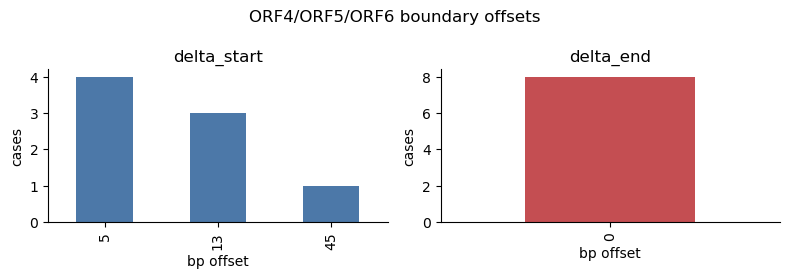

,record_id,pred_name,truth_name,best_overlap_name,ref_len,pred_len,truth_len,delta_start,delta_end,pred_minus_ref_len,truth_minus_ref_len,failure_mode,status,iou
87,DQ864705.1,ORF4,ORF4,ORF4,537,507,552.0,45.0,0.0,-30,15.0,Boundary offset,ok_rescued,0.9185
88,AY366525.1,ORF5,ORF5,ORF5,603,601,606.0,5.0,0.0,-2,3.0,Boundary offset,ok_rescued,0.9917
89,DQ489311.1,ORF5,ORF5,ORF5,603,601,606.0,5.0,0.0,-2,3.0,Boundary offset,ok_rescued,0.9917
90,DQ864705.1,ORF5,ORF5,ORF5,603,601,606.0,5.0,0.0,-2,3.0,Boundary offset,ok_rescued,0.9917
91,EU076704.1,ORF5,ORF5,ORF5,603,601,606.0,5.0,0.0,-2,3.0,Boundary offset,ok_rescued,0.9917
92,AY366525.1,ORF6,ORF6,ORF6,525,509,522.0,13.0,0.0,-16,-3.0,Boundary offset,ok_rescued,0.9751
93,DQ864705.1,ORF6,ORF6,ORF6,525,509,522.0,13.0,0.0,-16,-3.0,Boundary offset,ok_rescued,0.9751
94,EU076704.1,ORF6,ORF6,ORF6,525,509,522.0,13.0,0.0,-16,-3.0,Boundary offset,ok_rescued,0.9751


In [87]:
plot_delta_patterns(minor_evidence, 'ORF4/ORF5/ORF6 boundary offsets', 'prrsv_minor_boundary_delta_patterns.png')
minor_display_cols = [
    'record_id', 'pred_name', 'truth_name', 'best_overlap_name', 'ref_len', 'pred_len', 'truth_len',
    'delta_start', 'delta_end', 'pred_minus_ref_len', 'truth_minus_ref_len',
    'failure_mode', 'status', 'coverage', 'identity', 'iou'
]
minor_evidence[[c for c in minor_display_cols if c in minor_evidence.columns]].sort_values(['pred_name', 'record_id']).head(40)

## PRRSV-Specific Final Adjudication

These labels summarize the evidence above. They are reviewable rules, not hidden assumptions.

In [88]:
def _is_missing(value):
    return pd.isna(value) or value == ''


def _near_zero(value, tol=0):
    return pd.notna(value) and abs(value) <= tol


def _matches_ref_len(row):
    return pd.notna(row.get('pred_minus_ref_len')) and row.get('pred_minus_ref_len') == 0


def _truth_differs_ref_len(row):
    return pd.notna(row.get('truth_minus_ref_len')) and row.get('truth_minus_ref_len') != 0


def _prrsv_final_reason(row):
    pred = row.get('pred_name')
    truth = row.get('truth_name')
    best = row.get('best_overlap_name')
    failure_mode = row.get('failure_mode')
    status = row.get('status')
    delta_start = row.get('delta_start')
    delta_end = row.get('delta_end')
    truth_absent = _is_missing(truth)

    if pred == 'ORF2b' and truth_absent and best == 'ORF2a':
        return pd.Series({
            'final_blame': 'truth_gap',
            'final_cause': 'orf2b_truth_absent_overlaps_orf2a',
            'mechanism': 'ORF2b truth gap / ORF2a overlap',
            'final_explanation': 'Tool lifted ORF2b from ref, but query validation truth lacks ORF2b and the region overlaps ORF2a.',
        })

    if pred in {'ORF1a', 'ORF1b'} and best == 'ORF1ab':
        return pd.Series({
            'final_blame': 'annotation_convention',
            'final_cause': 'orf1a_orf1b_vs_orf1ab_granularity_mismatch',
            'mechanism': 'ORF1a/ORF1b vs ORF1ab granularity',
            'final_explanation': 'Reference/query split ORF1a/ORF1b differently from truth ORF1ab, so exact-name comparison is not biologically equivalent.',
        })

    if truth_absent:
        return pd.Series({
            'final_blame': 'truth_gap',
            'final_cause': 'truth_feature_absent',
            'mechanism': 'truth feature absent',
            'final_explanation': 'Prediction has no same-name truth feature in query validation truth.',
        })

    if pred == 'ORF1b' and failure_mode == 'Boundary offset' and _near_zero(delta_end):
        return pd.Series({
            'final_blame': 'annotation_convention',
            'final_cause': 'orf1b_frameshift_start_boundary_convention',
            'mechanism': 'ORF1b frameshift/start boundary',
            'final_explanation': 'ORF1b end matches truth while start shifts around the frameshift/start boundary.',
        })

    if pred == 'ORF7' and _near_zero(delta_end) and pd.notna(delta_start) and int(delta_start) in {43, 48}:
        if _matches_ref_len(row) and _truth_differs_ref_len(row):
            return pd.Series({
                'final_blame': 'annotation_convention',
                'final_cause': 'orf7_ref_boundary_shorter_than_truth',
                'mechanism': 'ORF7 ref/truth boundary convention',
                'final_explanation': 'Prediction follows ref-length ORF7, while query truth is longer at the N-terminus.',
            })
        return pd.Series({
            'final_blame': 'tool',
            'final_cause': 'orf7_n_terminal_boundary_offset_candidate',
            'mechanism': 'ORF7 N-terminal boundary candidate tool issue',
            'final_explanation': 'ORF7 keeps the same end but misses the N-terminal boundary relative to truth.',
        })

    if _matches_ref_len(row) and _truth_differs_ref_len(row):
        return pd.Series({
            'final_blame': 'annotation_convention',
            'final_cause': 'ref_query_boundary_convention_mismatch',
            'mechanism': 'ref/query boundary convention mismatch',
            'final_explanation': 'Prediction length matches ref, while truth length differs.',
        })

    if failure_mode == 'Boundary offset' and bool(row.get('coord_correct')):
        return pd.Series({
            'final_blame': 'tool',
            'final_cause': 'minor_boundary_offset_matches_neither_ref_nor_truth',
            'mechanism': 'minor boundary offset candidate tool issue',
            'final_explanation': 'Same-name truth exists and IoU is high, but exact boundary differs and ref length does not explain the offset.',
        })

    if status == 'no_hit' or failure_mode == 'Not lifted':
        return pd.Series({
            'final_blame': 'tool',
            'final_cause': 'no_hit',
            'mechanism': 'no hit',
            'final_explanation': 'Same-name truth exists, but tblastn did not produce a usable lifted feature.',
        })

    if failure_mode == 'Wrong coords':
        return pd.Series({
            'final_blame': 'tool',
            'final_cause': 'wrong_coordinates',
            'mechanism': 'wrong coordinates candidate tool issue',
            'final_explanation': 'Same-name truth exists, but coordinates are below correctness threshold.',
        })

    if failure_mode in {'Alias/name gap', 'Possible overlap'}:
        return pd.Series({
            'final_blame': 'annotation_convention',
            'final_cause': 'overlap_or_name_granularity_mismatch',
            'mechanism': 'overlap/name granularity mismatch',
            'final_explanation': 'Prediction overlaps another truth feature, suggesting annotation granularity/name mismatch.',
        })

    return pd.Series({
        'final_blame': 'tool',
        'final_cause': 'unclassified_tool_failure',
        'mechanism': 'unclassified tool-side candidate',
        'final_explanation': 'No annotation-convention or truth-gap rule explained this case.',
    })


final_cases = failures.copy()
if final_cases.empty:
    for col in ['final_blame', 'final_cause', 'mechanism', 'final_explanation']:
        final_cases[col] = []
else:
    final_cases = pd.concat([final_cases, final_cases.apply(_prrsv_final_reason, axis=1)], axis=1)

final_cases.to_csv(OUTPUT_DIR / 'prrsv_failure_final_cases.tsv', sep='	', index=False)

mechanism_summary = (
    final_cases.groupby(['final_blame', 'mechanism', 'final_cause'], dropna=False)
    .agg(
        cases=('record_id', 'size'),
        genes=('pred_name', lambda s: ', '.join(sorted(set(map(str, s.dropna()))))),
        main_failure_mode=('failure_mode', _top_value),
        main_status=('status', _top_value),
        delta_start_pattern=('delta_start', _format_delta),
        delta_end_pattern=('delta_end', _format_delta),
        pred_minus_ref_pattern=('pred_minus_ref_len', _format_delta),
        truth_minus_ref_pattern=('truth_minus_ref_len', _format_delta),
        mean_iou=('iou', 'mean'),
        mean_best_iou=('best_iou', 'mean'),
    )
    .reset_index()
    .sort_values('cases', ascending=False)
)
mechanism_summary['percent_of_non_exact'] = (mechanism_summary['cases'] / len(final_cases) * 100).round(2) if len(final_cases) else 0
mechanism_summary['mean_iou'] = mechanism_summary['mean_iou'].round(4)
mechanism_summary['mean_best_iou'] = mechanism_summary['mean_best_iou'].round(4)
mechanism_summary.to_csv(OUTPUT_DIR / 'prrsv_failure_mechanism_summary.tsv', sep='	', index=False)

blame_summary = (
    final_cases.groupby('final_blame', dropna=False)
    .size()
    .reset_index(name='cases')
    .assign(percent_of_non_exact=lambda d: (d['cases'] / len(final_cases) * 100).round(2) if len(final_cases) else 0)
    .sort_values('cases', ascending=False)
)
blame_summary.to_csv(OUTPUT_DIR / 'prrsv_failure_final_blame_summary.tsv', sep='	', index=False)
mechanism_summary

,final_blame,mechanism,final_cause,cases,genes,main_failure_mode,main_status,delta_start_pattern,delta_end_pattern,pred_minus_ref_pattern,truth_minus_ref_pattern,mean_iou,mean_best_iou,percent_of_non_exact
0,annotation_convention,ORF1b frameshift/start boundary,orf1b_frameshift_start_boundary_convention,83,ORF1b,Boundary offset,invalid_boundaries,"-75:1, -12:39, -9:2, -3:28, 6:12, 15:1",0:83,"-27:1, -3:1, 0:80, 3:1","-75:1, -15:1, -12:38, -9:3, -3:28, 6:12",0.9980,0.9980,67.48
1,tool,ORF7 N-terminal boundary candidate tool issue,orf7_n_terminal_boundary_offset_candidate,28,ORF7,Wrong coords,ok_rescued,"43:25, 48:3",0:28,"-43:25, -33:3","0:25, 15:3",0.8835,0.8835,22.76
2,tool,minor boundary offset candidate tool issue,minor_boundary_offset_matches_neither_ref_nor_...,12,"ORF1a, ORF2b, ORF4, ORF5, ORF6",Boundary offset,ok_rescued,"-5:3, 0:1, 5:4, 13:3, 45:1","0:11, 13:1","-30:1, -16:3, -4:3, -2:4, 108:1","-9:3, -3:3, 3:4, 15:1, 95:1",0.9784,0.9784,9.76


In [89]:
blame_summary

,final_blame,cases,percent_of_non_exact
0,annotation_convention,83,67.48
1,tool,40,32.52


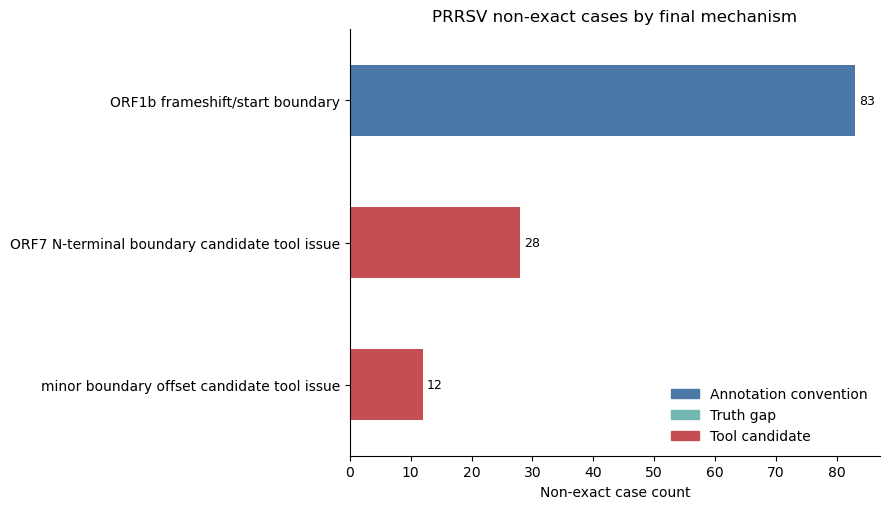

In [90]:
if not final_cases.empty:
    plot_df = mechanism_summary.sort_values('cases', ascending=True).copy()
    color_map = {'annotation_convention': '#4c78a8', 'truth_gap': '#72b7b2', 'tool': '#c44e52'}
    colors = plot_df['final_blame'].map(color_map).fillna('#999999')
    ax = plot_df.plot(kind='barh', x='mechanism', y='cases', color=colors, figsize=(9, 5.2), legend=False)
    ax.set_title('PRRSV non-exact cases by final mechanism')
    ax.set_xlabel('Non-exact case count')
    ax.set_ylabel('')
    for container in ax.containers:
        ax.bar_label(container, padding=3, fontsize=9)
    handles = [plt.Rectangle((0, 0), 1, 1, color=color) for color in color_map.values()]
    ax.legend(handles, ['Annotation convention', 'Truth gap', 'Tool candidate'], frameon=False, loc='lower right')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'prrsv_final_mechanism_summary.png', bbox_inches='tight')
    plt.show()

## Representative Case Table

In [91]:
case_cols = [
    'record_id', 'ref_name', 'pred_name', 'truth_name', 'best_overlap_name',
    'pred_start', 'pred_end', 'truth_start', 'truth_end',
    'delta_start', 'delta_end', 'pred_len', 'truth_len', 'ref_len',
    'pred_minus_ref_len', 'truth_minus_ref_len', 'pred_minus_truth_len',
    'failure_mode', 'final_blame', 'mechanism', 'final_cause', 'status',
    'coverage', 'identity', 'iou', 'best_iou', 'final_explanation',
]
case_table = final_cases[[col for col in case_cols if col in final_cases.columns]].copy()
case_table = case_table.sort_values(['final_blame', 'mechanism', 'pred_name', 'record_id'], na_position='last')
case_table.to_csv(OUTPUT_DIR / 'prrsv_failure_final_case_table.tsv', sep='	', index=False)
case_table.head(100)

,record_id,ref_name,pred_name,truth_name,best_overlap_name,pred_start,pred_end,truth_start,truth_end,delta_start,delta_end,pred_len,truth_len,ref_len,pred_minus_ref_len,truth_minus_ref_len,pred_minus_truth_len,failure_mode,final_blame,mechanism,final_cause,status,iou,best_iou,final_explanation
67,AB288356.1,ORF1b,ORF1b,ORF1b,ORF1b,7676,12061,7688.0,12061.0,-12.0,0.0,4386,4374.0,4386,0,-12.0,12.0,Boundary offset,annotation_convention,ORF1b frameshift/start boundary,orf1b_frameshift_start_boundary_convention,invalid_boundaries,0.9973,0.9973,ORF1b end matches truth while start shifts aro...
79,AB811785.1,ORF1b,ORF1b,ORF1b,ORF1b,7651,12036,7663.0,12036.0,-12.0,0.0,4386,4374.0,4386,0,-12.0,12.0,Boundary offset,annotation_convention,ORF1b frameshift/start boundary,orf1b_frameshift_start_boundary_convention,invalid_boundaries,0.9973,0.9973,ORF1b end matches truth while start shifts aro...
80,AB811786.1,ORF1b,ORF1b,ORF1b,ORF1b,7652,12037,7664.0,12037.0,-12.0,0.0,4386,4374.0,4386,0,-12.0,12.0,Boundary offset,annotation_convention,ORF1b frameshift/start boundary,orf1b_frameshift_start_boundary_convention,invalid_boundaries,0.9973,0.9973,ORF1b end matches truth while start shifts aro...
81,AB811787.1,ORF1b,ORF1b,ORF1b,ORF1b,7652,12037,7664.0,12037.0,-12.0,0.0,4386,4374.0,4386,0,-12.0,12.0,Boundary offset,annotation_convention,ORF1b frameshift/start boundary,orf1b_frameshift_start_boundary_convention,invalid_boundaries,0.9973,0.9973,ORF1b end matches truth while start shifts aro...
82,AB811788.1,ORF1b,ORF1b,ORF1b,ORF1b,7653,12038,7665.0,12038.0,-12.0,0.0,4386,4374.0,4386,0,-12.0,12.0,Boundary offset,annotation_convention,ORF1b frameshift/start boundary,orf1b_frameshift_start_boundary_convention,invalid_boundaries,0.9973,0.9973,ORF1b end matches truth while start shifts aro...
83,AB811789.1,ORF1b,ORF1b,ORF1b,ORF1b,7632,12017,7644.0,12017.0,-12.0,0.0,4386,4374.0,4386,0,-12.0,12.0,Boundary offset,annotation_convention,ORF1b frameshift/start boundary,orf1b_frameshift_start_boundary_convention,invalid_boundaries,0.9973,0.9973,ORF1b end matches truth while start shifts aro...
17,AF066183.4,ORF1b,ORF1b,ORF1b,ORF1b,7687,12072,7699.0,12072.0,-12.0,0.0,4386,4374.0,4386,0,-12.0,12.0,Boundary offset,annotation_convention,ORF1b frameshift/start boundary,orf1b_frameshift_start_boundary_convention,invalid_boundaries,0.9973,0.9973,ORF1b end matches truth while start shifts aro...
2,AF159149.1,ORF1b,ORF1b,ORF1b,ORF1b,7662,12047,7656.0,12047.0,6.0,0.0,4386,4392.0,4386,0,6.0,-6.0,Boundary offset,annotation_convention,ORF1b frameshift/start boundary,orf1b_frameshift_start_boundary_convention,invalid_boundaries,0.9986,0.9986,ORF1b end matches truth while start shifts aro...
6,AF176348.2,ORF1b,ORF1b,ORF1b,ORF1b,7686,12071,7680.0,12071.0,6.0,0.0,4386,4392.0,4386,0,6.0,-6.0,Boundary offset,annotation_convention,ORF1b frameshift/start boundary,orf1b_frameshift_start_boundary_convention,invalid_boundaries,0.9986,0.9986,ORF1b end matches truth while start shifts aro...
1,AF184212.1,ORF1b,ORF1b,ORF1b,ORF1b,7795,12180,7789.0,12180.0,6.0,0.0,4386,4392.0,4386,0,6.0,-6.0,Boundary offset,annotation_convention,ORF1b frameshift/start boundary,orf1b_frameshift_start_boundary_convention,invalid_boundaries,0.9986,0.9986,ORF1b end matches truth while start shifts aro...


## Notebook-Level Conclusion

Raw PRRSV exact accuracy is affected by annotation conventions and true overlapping CDS structure.

Expected after the target-aware truth filter:

- ORF2b is no longer all-fail: records with ORF2b truth are scored normally.
- ORF1b remains mostly non-exact because start boundary differs around frameshift/start convention, while end is usually exact.
- ORF1a failures are largely ORF1ab granularity mismatches.
- ORF7 remains the main candidate tool-side boundary issue.

Do not change the PRRSV algorithm until representative ORF7/minor-boundary cases are manually reviewed.